<a href="https://colab.research.google.com/github/loisvanessaadams-create/Lab-3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Lois Vanessa Adams
**Student ID:** 69312028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [6]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
'''feeds data into the model in batches, TensorDataset puts labels to images'''

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device: used to choose where to perform calculations, GPU(CUDA): a graphics card that can perform many calculations in parallel,making deep learning much faster'''

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
# use this everywhere so your results are reproducible, this is used whenever you need random numbers start from their fixed seed.
np.random.seed(RANDOM_STATE)
#Helps to to generate random sequences for numbers

print("Running on:", DEVICE)
#This simply displays which device PyTorch selected

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.



### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

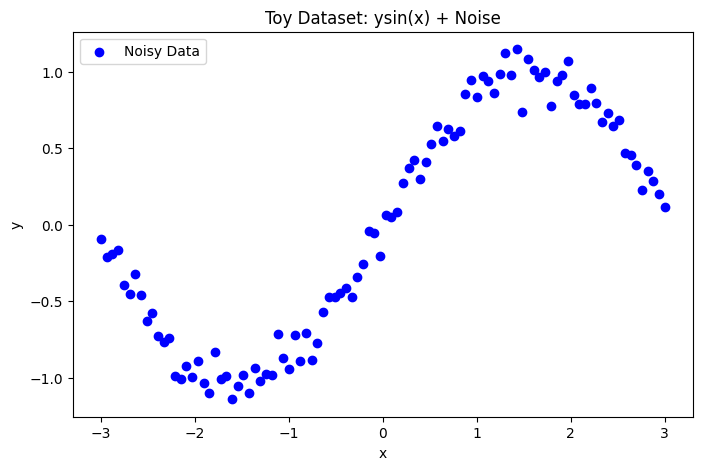

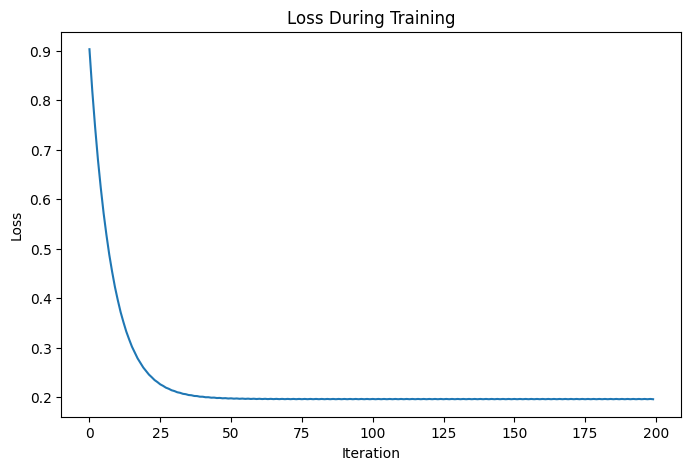

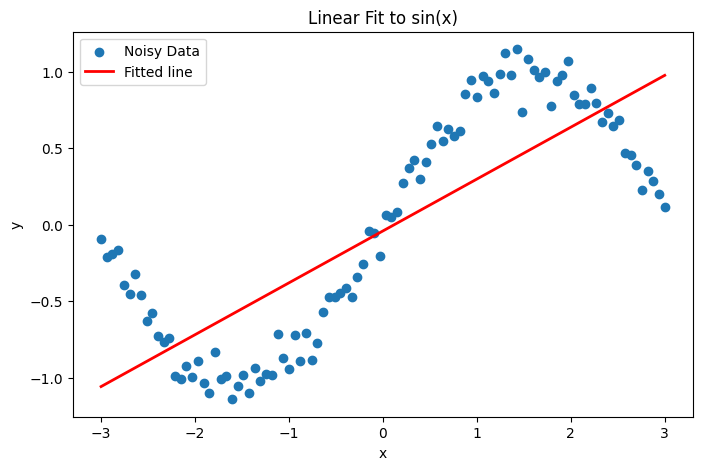

In [7]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

#Generating 100 evenly spaced x-values from -3 to 3
x = np.linspace(-3,3,100)
#Computing the true sine calues and add Gaussian noise
y = np.sin(x) + np.random.normal(0,0.1,size = x.shape)
#plotting the noisy data
plt.figure(figsize=(8,5))
plt.scatter(x,y,color="blue",label = "Noisy Data")
plt.title("Toy Dataset: ysin(x) + Noise")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# TODO: Initialise w and b to small random values.

#Randomly initialise the weight
w = np.random.randn() * 0.1

#Randomly initialise the bias
b = np.random.randn() * 0.1

#Learning rate
lr = 0.01

loss_history = []
#Gradient Descent
for step in range(200):
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#forward pass(prediction)
  y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)
 #mean squared error loss
  loss = np.mean((y_hat - y)** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))
#Compute gradients
  dw = np.mean(2 *(y_hat - y) * x )
  db = np.mean(2 * (y_hat - y))               # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#updating the parameters
  w -= lr * dw
  b -= lr + db
#   Record the loss at every step.
  #Save loss
  loss_history.append(loss)

# TODO: Plot
#(a) the loss curve over the 200 steps,
#Plotting the loss curve
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Loss During Training")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

#(b) the data with the fitted line on top.
#plotted fitted line
plt.figure(figsize=(8,5))
plt.scatter(x,y,label="Noisy Data")
plt.plot(x,w*x+b,color = "red",linewidth = 2,label = "Fitted line")
plt.title("Linear Fit to sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** This is underfitting because a single neuron produces only a straight line of the form y=wx +b, while a sine wave is non-linnear and curved. Training for more epochs can find the best possible straight line but it cannot change the model into a curved function.

solve dloss/dw


### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

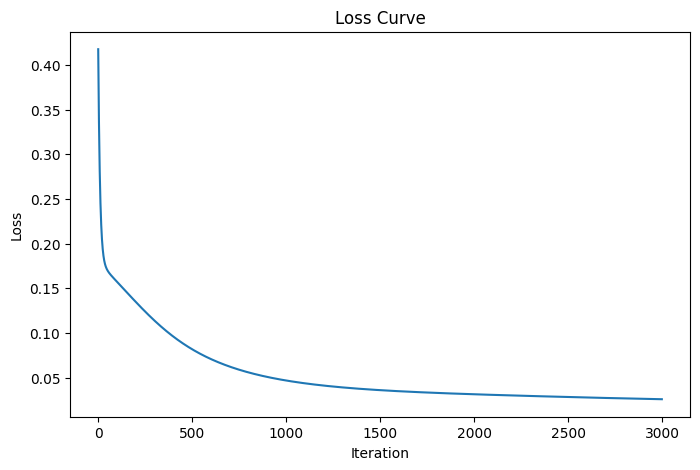

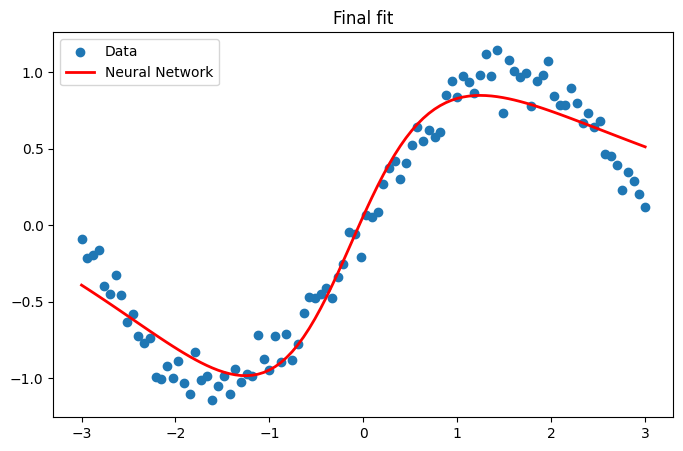

NameError: name 'b1_linear' is not defined

In [9]:
#Reshape Data
x = x.reshape(-1,1)
y = y.reshape(-1,1)


#   W1: shape (1, 8),  b1: shape (8,)
W1 = np.random.randn(1,8) * 0.5
b1 = np.random.randn(8) * 0.5
#   W2: shape (8, 1),  b2: shape (1,)
W2 = np.random.randn(8,1) *0.5
b2 = np.random.randn(1) * 0.5

lr = 0.01
loss_history = []
#   Small random values (e.g. np.random.randn(...) * 0.5)

for step in range(3000):
#forward pass
  z1 = x @ W1 + b1
  h = np.tanh(z1)
  y_hat = h @ W2 + b2
  loss = np.mean((y_hat - y)** 2)
# TODO: Backward pass (the chain rule, layer by layer):
#backward pass
  d_yhat = 2 * (y_hat - y) / len(y)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis = 0)
  dh = d_yhat @ W2.T
  dz1 = dh * (1-np.tanh(z1)**2)
  dW1 = x.T @ dz1
  db1 = dz1.sum(axis = 0)
# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
  W2 -= lr * dW2
  b2 -= lr * db2
  W1 -= lr * dW1
  b1 -= lr * db1
  loss_history.append(loss)

# TODO: Plot the loss curve AND the final fit over the data.
plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

y_pred = np.tanh(x @ W1 + b1) @ W2 + b2
plt.figure(figsize=(8,5))
plt.scatter(x,y,label="Data")
plt.plot(x,y_pred,color="red",linewidth=2,label="Neural Network")
plt.legend()
plt.title("Final fit")
plt.show()
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
## Plot Loss
W1_linear = np.random.randn(1,8) * 0.5
b1_linear1 = np.random.randn(8) * 0.5
W2_linear = np.random.randn(8,1) *0.5
b2_linear = np.random.randn(1) * 0.5

linear_loss_history = []

for step in range(3000):
  #Forward pass
  z1_linear = x @ W1_linear + b1_linear
  h_linear = z1_linear
  y_hat_linear = h_linear @ W2_linear + b2_linear
  loss_linear = np.mean((y_hat_linear - y)** 2)

  #Backward Pass
  d_yhat_linear = 2 * (y_hat_linear - y) / len(y)
  dW2_linear = h_linear.T @ d_yhat_linear
  db2_linear = d_yhat_linear.sum(axis = 0)
  dh_linear = d_yhat_linear @ W2_linear.T
  dz1_linear = dh_linear

  dW1_linear = x.T @ dz1_linear
  db1_linear = dz1_linear.sum(axis = 0)

  #Updating parameters
  W2_linear -= lr * dW2_linear
  b2_linear -= lr * db2_linear
  W1_linear -= lr * dW1_linear
  b1_linear -= lr * db1_linear

  linear_loss_history.append(loss_linear)


plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Loss Curve (Without tanh)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

# Plot Final Fit
y_pred_linear = (x @ W1_linear + b1_linear) @ W2_linear + b2_linear

plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Data")
plt.plot(x, y_pred, color="red", linewidth=2, label="Without tanh")
plt.title("Linear Network without tanh)")
plt.legend()
plt.show()

h_final = np.tanh(x @ W1 + b1)
#Plotting hidden neurons
plt.figure(figsize=(8,5))
for i in range(4):
  plt.plot(x,h_final[:,i],label = f"Hidden Neuron {i + 1}")

plt.xlabel("x")
plt.ylabel("Activation")
plt.title("hidden neuron activatio")
plt.legend()
plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:**
***1. without tanh***
h = xW1 + b1
y_hat = hW2 + b2
y_hat = (xW1 + b1)W2 + b2
y_hat =x(W1W2) + (b1W2 + b2)
W = W1W2
b = b1W2 + b2
y_hat =xW + b
This shows the whole network is just one linear function.

***2. Each hidden neuron learned a different transformed version of the input:
hj = tanh(xW1j + b1j)***

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

In [ ]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps=3000):
  np.random.seed(RANDOM_STATE)
  #initializing parameters
  W1 = np.random.randn(1,8) * 0.5
  b1 = np.random.randn(8) * 0.5
  W2 = np.random.randn(8,1) * 0.5
  b2 = np.random.randn(1) * 0.5

  losses = []

  for step in range(steps):
    #forward pass
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - y) ** 2)

    #backward pass
    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis = 0)

    #Updates
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    losses.append(loss)

  return losses
# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
loss_1 = train_toy(0.001)
loss_2 = train_toy(0.05)
loss_3 = train_toy(1.0)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(8,5))
plt.plot(loss_1,label="lr = 0.001")
plt.plot(loss_2,label = "lr = 0.05")
plt.plot(loss_3,label = "lr = 1.0")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** [Double-click to edit]

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
obesity_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(obesity_URL)
print("Original shape: ", obesity.shape)
obesity.head()

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
binary_cols = [
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC"
    ]
for col in binary_cols:
  obesity[col] = obesity[col].map({"yes" : 1,"no" : 0})

obesity = pd.get_dummies(obesity,
                          columns = ["Gender","CAEC","CALC","MTRANS"],
                          drop_first = True
  )

obesity["BMI"] = obesity["Weight"]/(obesity["Height"]** 2)

#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
obesity["NObeyesdad"] = label_encoder.fit_transform(obesity["NObeyesdad"])

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
x = obesity.drop("NObeyesdad",axis = 1)
y = obesity["NObeyesdad"]

x_train, x_temp, y_train, y_temp = train_test_split(
   x,y,test_size = 0.4,stratify =y,random_state = RANDOM_STATE
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp,test_size = 0.5, stratify = y_temp,
    random_state = RANDOM_STATE
)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)
# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
x_train_tensor = torch.tensor(x_train_scaled,dtype = torch.float32)
x_val_tensor = torch.tensor(x_val_scaled,dtype = torch.float32)
x_test_tensor = torch.tensor(x_test_scaled,dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(),dtype = torch.long)
y_val_tensor = torch.tensor(y_val.to_numpy(),dtype = torch.long)
y_test_tensor = torch.tensor(y_test.to_numpy(),dtype = torch.long)

train_dataset = TensorDataset(x_train_tensor,y_train_tensor)
val_dataset = TensorDataset(x_val_tensor,y_val_tensor)
test_dataset = TensorDataset(x_test_tensor,y_test_tensor)

train_loader = DataLoader(train_dataset,batch_size = 32,shuffle = True)
val_loader = DataLoader(val_dataset,batch_size = 32,shuffle = False)
test_loader = DataLoader(test_dataset,batch_size = 32,shuffle = False)

**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** [Double-click to edit]

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [ ]:
from concurrent.futures import FIRST_COMPLETED
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...
class FeedForwardNet(nn.Module):
  def __init__(self,input_dim,hidden_sizes = (64,32),n_classes = 7):
    super().__init__()

    self.network = nn.Sequential(
        nn.Linear(input_dim,hidden_sizes[0]),
        nn.ReLU(),

        nn.Linear(hidden_sizes[0],hidden_sizes[1]),
        nn.ReLU(),
        nn.Linear(hidden_sizes[1],n_classes)
    )
  def forward(self,x):
    return self.network(x)

# TODO: Instantiate, move to DEVICE, print the model.
input_dim = x_train_tensor.shape[1]
model = FeedForwardNet(input_dim=input_dim,hidden_sizes = (64,32),
                       n_classes = 7).to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)
print("Number of trainable parameters:", trainable_parameters)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** [Double-click to edit]

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

In [ ]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=le-3)
# TODO: Train for at least 50 epochs. Each epoch:
epochs = 50
train_losses = []
val_losses = []
train_accuracies = []
val-accuracies = []
best_val_accuracy =0.0

for epoch in range(epochs):
  model.train()

  running_train_loss = 0.0
  train_correct = 0
  train_total = 0

  for xb,yb in train_loader:
    xb = xb.to(DEVICE)


#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** [Double-click to edit]

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [ ]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** [Double-click to edit]

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [ ]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.